# 11.01 Graph SLAM 실습 — 방 안을 돌고 돌아 Loop Closure로 보정하기

**목표:**  ROS2의 Graph SLAM 핵심 원리를 Python 시뮬레이션으로 직접 체감합니다.

## Step 1 — 라이브러리 임포트 & 시뮬레이션 환경 설정

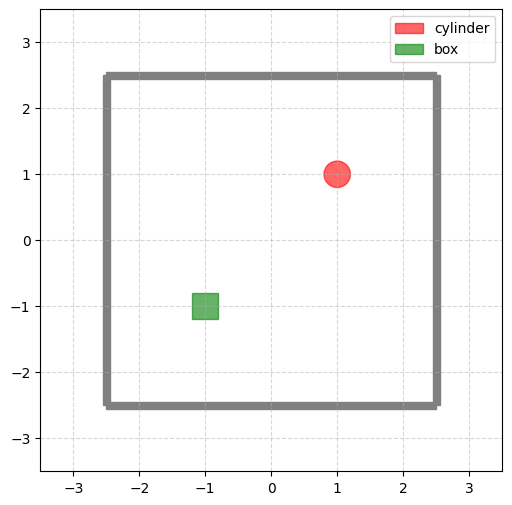

✅ Step 1 완료 — 시뮬레이션 환경 준비


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import warnings
warnings.filterwarnings('ignore')

# 시뮬레이션 상수
ROOM_SIZE = 5.0          # 방 크기 (m)
MOVE_DIST = 0.4          # 한 스텝 전진 거리 (m)
ODOM_NOISE_RATIO = 0.25  # 오도메트리 노이즈 비율 (25%)
LIDAR_RANGE = 3.5        # LiDAR 최대 거리
LIDAR_RAYS = 36          # LiDAR 레이 개수 (10도 간격)

np.random.seed(42)

def draw_room_world(ax):
    """방 환경 시각화 함수 (벽 및 장애물)"""
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5); ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

    # 4면 벽 생성
    walls = [
        Rectangle((-2.5,  2.45), 5.0, 0.1, color='gray'),   # 북
        Rectangle((-2.5, -2.55), 5.0, 0.1, color='gray'),   # 남
        Rectangle(( 2.45, -2.5), 0.1, 5.0, color='gray'),   # 동
        Rectangle((-2.55, -2.5), 0.1, 5.0, color='gray'),   # 서
    ]
    for w in walls: ax.add_patch(w)

    # 내부 장애물
    ax.add_patch(Circle((1.0, 1.0), 0.2, color='red', alpha=0.6, label='cylinder'))
    ax.add_patch(Rectangle((-1.2, -1.2), 0.4, 0.4, color='green', alpha=0.6, label='box'))
    ax.legend(loc='upper right')

fig, ax = plt.subplots(figsize=(6, 6))
draw_room_world(ax)
plt.show()
print("✅ Step 1 완료 — 시뮬레이션 환경 준비")

## Step 2 — 2D Pose & 수학 유틸리티 (Homogeneous Transform)

로봇의 2D 위치 $(x, y, \theta)$를 계산할 때 삼각함수를 직접 쓰는 대신,
로보틱스에서 널리 쓰이는 **3x3 변환 행렬 (Transformation Matrix)**을 사용하면 직관적입니다.

In [2]:
def v2t(v):
    """[x, y, θ] → 3x3 변환 행렬"""
    x, y, th = v
    c, s = np.cos(th), np.sin(th)
    return np.array([[c, -s, x],
                     [s,  c, y],
                     [0,  0, 1]])

def t2v(T):
    """3x3 변환 행렬 → [x, y, θ]"""
    return np.array([T[0,2], T[1,2], np.arctan2(T[1,0], T[0,0])])

def pose_compose(xi, xj):
    """두 Pose의 합성 (이동 누적): xi ⊕ xj"""
    return t2v(v2t(xi) @ v2t(xj))

def relative_pose(xi, xj):
    """xi에서 xj로의 상대 Pose (상대 위치): ⊖xi ⊕ xj"""
    return t2v(np.linalg.inv(v2t(xi)) @ v2t(xj))

def noisy_odometry(true_delta, noise_ratio=ODOM_NOISE_RATIO):
    """이동 거리에 가우시안 노이즈 추가"""
    noise = np.random.randn(3) * noise_ratio * np.abs(true_delta)
    noise[2] *= 0.5  # 회전 노이즈는 직진보다 작게 반영
    return true_delta + noise

print("✅ Step 2 완료 — 2D 변환 행렬 함수 정의")

✅ Step 2 완료 — 2D 변환 행렬 함수 정의


## Step 3 — 시뮬레이션 궤적 생성 (Ground Truth vs Odometry)

로봇이 정사각형 경로를 따라 출발점으로 돌아오도록 시뮬레이션합니다.
* **Ground Truth**: 노이즈가 없는 실제 경로
* **Odometry**: 센서 노이즈가 누적되어 출발점으로 오지 못하는(Drift) 경로

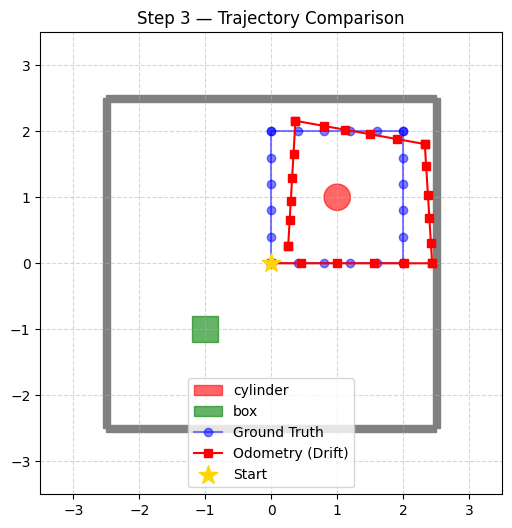

✅ Step 3 완료 — 오도메트리 누적 오차: 0.369 m


In [3]:
# 1. Ground Truth 괒적 만들기 (정사각형 루프)
gt_poses = [np.array([0.0, 0.0, 0.0])]
for side in range(4):
    for _ in range(5):  # 한 변당 5스텝 (0.4m x 5 = 2.0m)
        gt_poses.append(pose_compose(gt_poses[-1], [MOVE_DIST, 0.0, 0.0]))
    if side < 3: # 90도 좌회전
        gt_poses.append(pose_compose(gt_poses[-1], [0.0, 0.0, np.pi/2]))
gt_poses.append(pose_compose(gt_poses[-1], [0.0, 0.0, np.pi/2])) # 시작 방향 복귀
gt_poses = np.array(gt_poses)

# 2. 오도메트리 괒적 만들기 (Drift 발생)
odom_poses = [np.array([0.0, 0.0, 0.0])]
odom_deltas = []

for i in range(1, len(gt_poses)):
    true_delta = relative_pose(gt_poses[i-1], gt_poses[i])
    meas_delta = noisy_odometry(true_delta)

    odom_deltas.append(meas_delta)
    odom_poses.append(pose_compose(odom_poses[-1], meas_delta))
odom_poses = np.array(odom_poses)

# 3. 궤적 비교 시각화
fig, ax = plt.subplots(figsize=(6, 6))
draw_room_world(ax)
ax.plot(gt_poses[:,0], gt_poses[:,1], 'b-o', alpha=0.5, label='Ground Truth')
ax.plot(odom_poses[:,0], odom_poses[:,1], 'r-s', label='Odometry (Drift)')
ax.scatter(0, 0, c='gold', s=200, marker='*', zorder=5, label='Start')
ax.legend(); ax.set_title('Step 3 — Trajectory Comparison')
plt.show()

print(f"✅ Step 3 완료 — 오도메트리 누적 오차: {np.linalg.norm(odom_poses[-1,:2]):.3f} m")

## Step 4 — Pose Graph 구성 (Node & Edge)

Graph SLAM을 위해 로봇의 경로를 그래프로 모델링합니다.
- **Node**: 로봇의 Pose $(x, y, \theta)$
- **Edge**: 두 Node 사이의 상대 위치 측정값 (Odometry, Loop Closure)

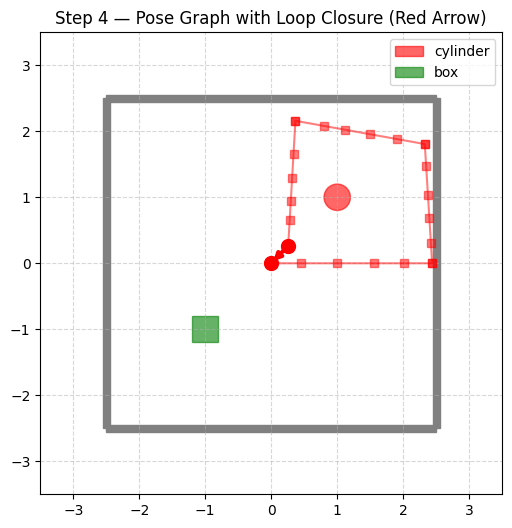

✅ Step 4 완료 — Pose Graph 구성 (노드, 오도메트리, 루프 클로저)


In [4]:
nodes = [p.copy() for p in odom_poses] # 초기 추정치는 Odometry
edges = []

# 1. Odometry Edge 추가 (연속된 노드 간)
info_odom = np.diag([1/(0.05**2), 1/(0.05**2), 1/(0.02**2)]) # 측정 신뢰도 (역공분산)
for i, z in enumerate(odom_deltas):
    edges.append({'from': i, 'to': i+1, 'z': z, 'info': info_odom, 'type': 'odom'})

# 2. Loop Closure Edge 추가 (시작점과 끝점이 만남)
# (실제로는 LiDAR Scan Matching을 통해 찾지만, 시뮬레이션이므로 Ground Truth에 약간의 노이즈를 섞어 생성)
true_lc = relative_pose(gt_poses[-1], gt_poses[0])
meas_lc = noisy_odometry(true_lc, noise_ratio=0.02)
info_lc = np.diag([1/(0.03**2), 1/(0.03**2), 1/(0.01**2)]) # Loop Closure는 비교적 신뢰도 높게 설정

edges.append({'from': len(nodes)-1, 'to': 0, 'z': meas_lc, 'info': info_lc, 'type': 'loop'})

# 그래프 시각화
fig, ax = plt.subplots(figsize=(6, 6))
draw_room_world(ax)
ax.plot(odom_poses[:,0], odom_poses[:,1], 'r-s', alpha=0.5)
# Loop Closure 엣지 강조
lc_e = edges[-1]
p1, p2 = odom_poses[lc_e['from']], odom_poses[lc_e['to']]
ax.annotate('', xy=(p2[0], p2[1]), xytext=(p1[0], p1[1]), arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.scatter([p1[0], p2[0]], [p1[1], p2[1]], c='red', s=100, zorder=5)
ax.set_title('Step 4 — Pose Graph with Loop Closure (Red Arrow)')
plt.show()

print("✅ Step 4 완료 — Pose Graph 구성 (노드, 오도메트리, 루프 클로저)")

## Step 5 — LiDAR Scan & Occupancy Map: GT vs Odometry 비교

GT 궤적과 Odometry 궤적에서 각각 LiDAR 스캔 포인트를 생성하여
오도메트리 드리프트가 맵 품질에 미치는 영향을 시각적으로 비교합니다.

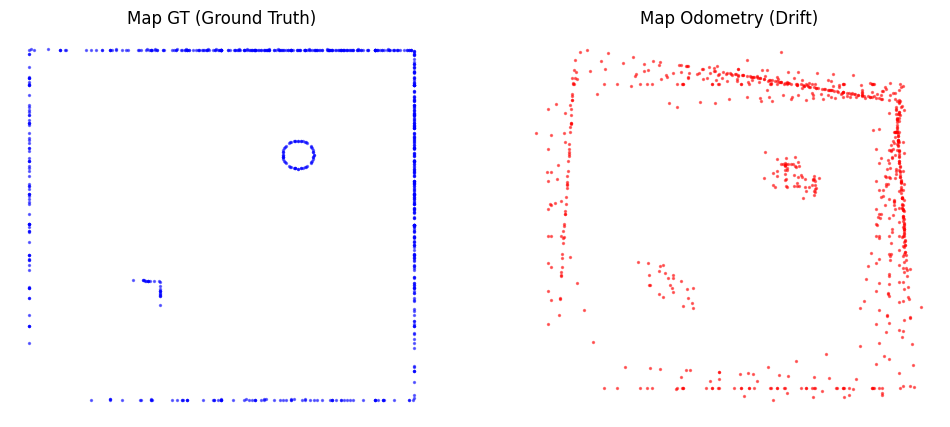

📊 GT vs Odometry 맵 품질 비교
  평균 궤적 오차 (Odometry): 0.3424 m


In [5]:
segments = [
    # 벽 (방 경계)
    np.array([[-2.5, -2.5], [ 2.5, -2.5]]), np.array([[-2.5,  2.5], [ 2.5,  2.5]]), # 남, 북
    np.array([[-2.5, -2.5], [-2.5,  2.5]]), np.array([[ 2.5, -2.5], [ 2.5,  2.5]]), # 서, 동
    # 박스 장애물
    np.array([[-1.2, -1.2], [-0.8, -1.2]]),  # 아래쪽 변
    np.array([[-0.8, -1.2], [-0.8, -0.8]]),  # 오른쪽 변
    np.array([[-0.8, -0.8], [-1.2, -0.8]]),  # 위쪽 변
    np.array([[-1.2, -0.8], [-1.2, -1.2]]),  # 왼쪽 변
]

def ray_cast(pose, angle, max_range=LIDAR_RANGE):
    """LiDAR Ray와 벽/장애물 교차점 계산"""
    ox, oy = pose[0], pose[1]
    dx, dy = np.cos(pose[2] + angle), np.sin(pose[2] + angle)
    closest = max_range

    # 선분(벽) 충돌
    for seg in segments:
        x1, y1, x2, y2 = *seg[0], *seg[1]
        denom = dx*(y1-y2) - dy*(x1-x2)
        if abs(denom) < 1e-9: continue
        t = ((x1-ox)*(y1-y2) - (y1-oy)*(x1-x2)) / denom
        u = -((x1-ox)*dy - (y1-oy)*dx) / denom
        if t > 0 and 0 <= u <= 1 and t < closest: closest = t

    # 원통 충돌
    cx, cy, cr = 1.0, 1.0, 0.2
    a, b = dx**2 + dy**2, 2*(ox-cx)*dx + 2*(oy-cy)*dy
    c = (ox-cx)**2 + (oy-cy)**2 - cr**2
    disc = b**2 - 4*a*c
    if disc >= 0:
        for t in [(-b - np.sqrt(disc))/(2*a), (-b + np.sqrt(disc))/(2*a)]:
            if t > 0 and t < closest: closest = t
    return closest

def get_map_points(poses):
    """주어진 궤적에서 LiDAR 스캔 포인트들을 월드 좌표계로 모음"""
    pts = []
    angles = np.linspace(0, 2*np.pi, LIDAR_RAYS, endpoint=False)
    for p in poses:
        for a in angles:
            d = ray_cast(p, a)
            if d < LIDAR_RANGE - 0.01:
                pts.append([p[0] + d * np.cos(p[2] + a), p[1] + d * np.sin(p[2] + a)])
    return np.array(pts)

# 실제 측정은 GT 위치에서 이루어지지만, 로봇은 자신의 위치를 GT/Odom 중 어디라고 믿느냐에 따라
# 같은 LiDAR 측정값을 서로 다른 월드 좌표로 변환해서 맵에 기록하게 됨
pts_gt = []
pts_odom = []
angles = np.linspace(0, 2*np.pi, LIDAR_RAYS, endpoint=False)

for gt, odom in zip(gt_poses, odom_poses):
    for a in angles:
        d = ray_cast(gt, a)           # 실제 측정은 GT 위치에서 수행
        if d < LIDAR_RANGE - 0.01:
            lx = d * np.cos(a)        # 로봇 좌표계 x
            ly = d * np.sin(a)        # 로봇 좌표계 y
            pts_gt.append((v2t(gt)    @ [lx, ly, 1])[:2])   # 정확한 좌표계로 변환
            pts_odom.append((v2t(odom) @ [lx, ly, 1])[:2])  # 틀린 좌표계로 변환

pts_gt = np.array(pts_gt)
pts_odom = np.array(pts_odom)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pts, title, color in zip(axes, [pts_gt, pts_odom],
                                 ['Map GT (Ground Truth)', 'Map Odometry (Drift)'], ['blue', 'red']):
    ax.scatter(pts[:,0], pts[:,1], s=2, c=color, alpha=0.5)
    ax.set_title(title)
    ax.axis('off')
plt.show()

err_odom = np.mean([np.linalg.norm(odom_poses[i,:2] - gt_poses[i,:2]) for i in range(len(gt_poses))])

print("="*50)
print("📊 GT vs Odometry 맵 품질 비교")
print(f"  평균 궤적 오차 (Odometry): {err_odom:.4f} m")
print("="*50)